In [1]:
import torch

def get_device():
  if torch.cuda.is_available():
    return torch.device('cuda')
  if hasattr(torch,'mps') and torch.backends.mps.is_available():
    return torch.device('mps')
  else:
    return torch.device('cpu')


device = get_device()
print(device)

cuda


In [12]:
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.5,),(0.5,))
])

train_dataset = datasets.MNIST(root='./data',train=True,transform=transform,download=True)
test_dataset = datasets.MNIST(root='./data',train=False,transform=transform,download=True)

train_loader = DataLoader(train_dataset,batch_size=256,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=256,shuffle=False)



In [18]:
import torch.nn as nn
import torch.nn.functional as F


class mynet(nn.Module):
    def __init__(self,input_size,hidden_size,hidden_size2,out_size):
        super(mynet, self).__init__()

        self.layer1 = nn.Linear(input_size,hidden_size)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size,hidden_size2)
        self.act2 = nn.LeakyReLU(negative_slope=0.01)
        self.layer3 = nn.Linear(hidden_size2,out_size)
        self.act3 = nn.Softmax(dim=1)

    def forward(self,x):
        x = x.view(x.size(0),-1)
        x = self.layer1(x)
        x = self.act1(x)
        x = self.layer2(x)
        x = self.act2(x)
        x = self.layer3(x)
        x = self.act3(x)
        return x

In [19]:
import torch.optim as optim

model = mynet(28*28,256,128,10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)


In [20]:
import wandb
wandb.login()


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

In [21]:
wandb_run = wandb.init(project='SDAIA_SEU',name='Exp1',reinit=True)

epoch loss,█▃▂▁▁
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇███
loss,█▅▅▄▄▃▃▂▃▂▃▂▃▁▂▂▁▂▁▂▁▂▂▂▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁
test accuracy,▁▆▇██
epoch loss,0.09243
global_step,5
loss,0.03026
test accuracy,96.76


In [22]:
from os import write
from tqdm import tqdm
epochs = 5
training_loss = []

for epoch in range(1,epochs+1):
  print("Epoch : ", epoch)
  running_loss = 0.0
  for i, data in enumerate(tqdm(train_loader),0):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    wandb.log({'loss':loss,'global_step':epoch*len(train_loader)+i})
    # writer.add_scalar('training loss',loss,epoch*len(train_loader)+i)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  training_loss.append(running_loss/len(train_loader))
  wandb.log({'epoch loss':running_loss/len(train_loader),'global_step':epoch})
  # writer.add_scalar('epoch loss',running_loss/len(train_loader),epoch)

  correct = 0
  total = 0
  test_labels = []
  test_preds = []

  with torch.no_grad():
      for data in test_loader:
          images, labels = data
          images = images.to(device)
          labels = labels.to(device)
          outputs = model(images)
          _,predicted_output = torch.max(outputs,1)
          total += labels.size(0)
          correct += (predicted_output == labels).sum().item()
          test_labels.extend(labels.cpu().numpy())
          test_preds.extend(predicted_output.cpu().numpy())
  wandb.log({'test accuracy':100 * correct / total,'global_step':epoch})
  # writer.add_scalar('test accuracy',100 * correct / total,epoch
  # writer.add_scalar('test accura?cy',100 * correct / total,epoch)
  print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))


Epoch :  1


100%|██████████| 235/235 [00:13<00:00, 17.32it/s]


Accuracy of the network on the 10000 test images: 82 %
Epoch :  2


100%|██████████| 235/235 [00:13<00:00, 17.70it/s]


Accuracy of the network on the 10000 test images: 84 %
Epoch :  3


...

Accuracy of the network on the 10000 test images: 85 %
Epoch :  4


100%|██████████| 235/235 [00:12<00:00, 18.14it/s]


Accuracy of the network on the 10000 test images: 86 %
Epoch :  5


100%|██████████| 235/235 [00:16<00:00, 13.91it/s]


Accuracy of the network on the 10000 test images: 86 %


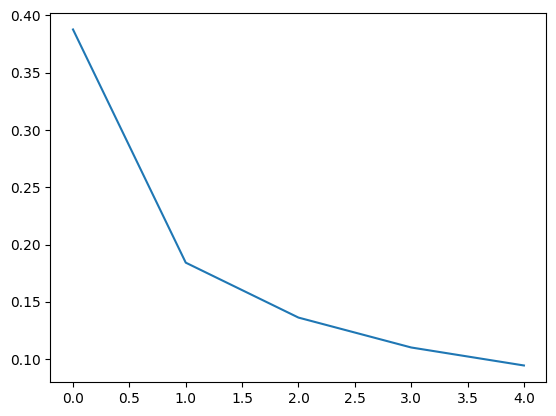

Accuracy of the network on the 10000 test images: 95 %


In [ ]:
import matplotlib.pyplot as plt


plt.plot(training_loss)
plt.show()

correct = 0
total = 0
test_labels = []
test_preds = []

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _,predicted_output = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted_output == labels).sum().item()
        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(predicted_output.cpu().numpy())

print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))